In [1]:
#!/usr/bin/env python
"""
LeafletFA Model Evaluation in Mouse 

This script:
1. Loads trained LeafletFA model outputs and associated data (mouse foundation smart-seq data)
2. Loads EasySci data (just brain) meta-cells anndata with junctions and ATSEs mapped using mouse foundation atse file
3. Applies the model to the EasySci data
4. Saves the predicted factor activities and factor usage
"""

import os
import sys
import glob
import pickle
import gzip
import warnings
from pathlib import Path
from collections import defaultdict
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

# Data analysis libraries
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage, dendrogram

# Machine learning libraries
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import (mean_squared_error, accuracy_score, r2_score, 
                           classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# Statistical modeling
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from mord import OrdinalRidge

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from adjustText import adjust_text

# Single-cell analysis libraries
import anndata as ad
import scanpy as sc

# Bioinformatics libraries
import gffutils
from tqdm import tqdm

# PyTorch setup
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA device name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.set_default_tensor_type("torch.FloatTensor" if device.type == "cpu" else "torch.cuda.FloatTensor")
torch.manual_seed(0)

# Configure plotting and warnings
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')
warnings.filterwarnings('ignore')

# =============================================================================
# Custom Module Imports
# =============================================================================

# Add custom module paths
leaflet_src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

for path in [leaflet_src_path, utils_path]:
    if path not in sys.path:
        sys.path.append(path)

# Import LeafletFA modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.utils as utilsFA

# Import utility functions
from utils import load_model
from utils import *
from figure_plotting import *
from atse_viz import *

# =============================================================================
# Database Setup
# =============================================================================

print("Loading genome databases...")

# Mouse genome database
mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

# Human genome database  
human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

print("✓ Genome databases loaded successfully")

Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!
Loading genome databases...
✓ Genome databases loaded successfully


In [2]:
# Mouse foundation data 
# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

# Load Mouse ATSEs
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")

# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-30"
MODEL_ANALYSIS_DATE = "2025-07-31"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files from downstream analysis of model 
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)
psi = leaflet_model["psi_learned"]

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")
print(f"Loaded psi: {psi.shape}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading model to device: cuda
Loaded splice_adata: (137936, 35197)
Loaded PI values: (20,)
Loaded diff_spl: (79097, 44)
Loaded psi: (20, 35197)
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


In [3]:
# Mapping file mouse --> human 
atse_mapping_file = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-08-14/junction_mapping_mouse_human_with_annotations.csv" 
atse_mapping = pd.read_csv(atse_mapping_file)
atse_mapping = atse_mapping[atse_mapping["mouse_junction_id"].isin(splice_adata.var["junction_id"])]

# Subset splice_adata to only include junctions that are in atse_mapping["mouse_junction_id"]
splice_adata = splice_adata[:, splice_adata.var["junction_id"].isin(atse_mapping["mouse_junction_id"])].copy()
print(f"Subsetted splice_adata: {splice_adata.shape}")
atse_df = splice_adata.var[["junction_id", "event_id"]]
atse_df.columns = ["mouse_junction_id", "event_id"]
# add atse event_id to atse_mapping  
atse_mapping = atse_mapping.merge(atse_df, on="mouse_junction_id", how="left")
atse_mapping = atse_mapping[["human_junction_id", "mouse_junction_id", "mouse_gene", "human_gene","event_id"]].drop_duplicates()

Subsetted splice_adata: (137936, 10651)


In [4]:
# Load the gtex anndata object  
gtex_anndata = ad.read_h5ad(f"/gpfs/commons/groups/knowles_lab/Karin/data/GTEx/v10/gtex_junctions_anndata.h5ad")

# add atse event_id to atse_mapping 
# keep only atses / junctions for which all junctions are available in gtex... 
# make proper counts layers... 
# Add "cell_by_junction_matrix" and "cell_by_cluster_matrix" layers to gtex_anndata
gtex_anndata.var["human_junction_id"] = gtex_anndata.var.index 
gtex_var_keep = gtex_anndata.var.merge(atse_mapping, on="human_junction_id")
gtex_anndata = gtex_anndata[:, gtex_anndata.var["human_junction_id"].isin(gtex_var_keep["human_junction_id"])].copy()
gtex_anndata.var = gtex_anndata.var.merge(atse_mapping, on="human_junction_id")
gtex_anndata.var 

,chrom,start,end,strand,gene_id,original_junction_id,human_junction_id,mouse_junction_id,mouse_gene,human_gene,event_id
0,chr1,1050837,1051252,+,ENSG00000188157.15,chr1:1050838-1051252:+,chr1_1050837_1051252_+,chr4_156169336_156169769_-,ENSMUSG00000041936,ENSG00000188157,ENSMUSG00000041936.18_atse_8
1,chr1,1051043,1051252,+,ENSG00000188157.15,chr1:1051044-1051252:+,chr1_1051043_1051252_+,chr4_156169336_156169545_-,ENSMUSG00000041936,ENSG00000188157,ENSMUSG00000041936.18_atse_8
2,chr1,1051815,1051992,+,ENSG00000188157.15,chr1:1051816-1051992:+,chr1_1051815_1051992_+,chr4_156168569_156168732_-,ENSMUSG00000041936,ENSG00000188157,ENSMUSG00000041936.18_atse_9
3,chr1,1051815,1053752,+,ENSG00000188157.15,chr1:1051816-1053752:+,chr1_1051815_1053752_+,chr4_156167506_156168732_-,ENSMUSG00000041936,ENSG00000188157,ENSMUSG00000041936.18_atse_9
4,chr1,1053493,1053752,+,ENSG00000188157.15,chr1:1053494-1053752:+,chr1_1053493_1053752_+,chr4_156167506_156167776_-,ENSMUSG00000041936,ENSG00000188157,ENSMUSG00000041936.18_atse_9
...,...,...,...,...,...,...,...,...,...,...,...
9826,chrX,154508597,154511847,-,ENSG00000071889.17,chrX:154508598-154511847:-,chrX_154508597_154511847_-,chrX_74387751_74390473_-,ENSMUSG00000031399,ENSG00000071889,ENSMUSG00000031399.15_atse_2
9827,chrX,154678294,154680131,-,ENSG00000160219.12,chrX:154678295-154680131:-,chrX_154678294_154680131_-,chrX_74988836_74990053_-,ENSMUSG00000032750,ENSG00000160219,ENSMUSG00000032750.13_atse_2
9828,chrX,154766400,154766996,+,ENSG00000130826.18,chrX:154766401-154766996:+,chrX_154766400_154766996_+,chrX_75098947_75100029_+,ENSMUSG00000031403,ENSG00000130826,ENSMUSG00000031403.14_atse_4
9829,chrX,154766400,154767255,+,ENSG00000130826.18,chrX:154766401-154767255:+,chrX_154766400_154767255_+,chrX_75098947_75100432_+,ENSMUSG00000031403,ENSG00000130826,ENSMUSG00000031403.14_atse_4


In [5]:
# Now update splice_adata to only include junctions that are in gtex_anndata.var["human_junction_id"]   
splice_adata = splice_adata[:, splice_adata.var["junction_id"].isin(gtex_anndata.var["mouse_junction_id"])].copy()

In [6]:
# Count actual junctions per event_id
actual_junction_counts = splice_adata.var.groupby("event_id")["junction_id"].nunique()

# Get expected junction counts per event_id
expected_junction_counts = splice_adata.var.groupby("event_id")["num_junctions"].first()

# Create comparison dataframe
junction_comparison = pd.DataFrame({
    'event_id': actual_junction_counts.index,
    'actual_junctions': actual_junction_counts.values,
    'expected_junctions': expected_junction_counts.values
})

# Check for mismatches
junction_comparison['match'] = (junction_comparison['actual_junctions'] == 
                               junction_comparison['expected_junctions'])

# Keep just those where match is True 
junction_comparison = junction_comparison[junction_comparison['match']]
print(f"Number of remaining ATSEs to look at: {len(junction_comparison)}")

Number of remaining ATSEs to look at: 1689


In [7]:
# Final time subsetting splice_adata and gtex_anndata to only include only the ATSEs listed in junction_comparison
splice_adata = splice_adata[:, splice_adata.var["event_id"].isin(junction_comparison["event_id"])].copy()
gtex_anndata = gtex_anndata[:, gtex_anndata.var["event_id"].isin(junction_comparison["event_id"])].copy()

print(f"Final splice_adata shape: {splice_adata.shape}")
print(f"Final gtex_anndata shape: {gtex_anndata.shape}")

Final splice_adata shape: (137936, 4381)
Final gtex_anndata shape: (16622, 4381)


In [8]:
print("Creating cell_by_cluster_matrix (same dimensions as junction matrix)...")

# Set up junction matrix
gtex_anndata.layers["cell_by_junction_matrix"] = gtex_anndata.layers["counts"]
junction_matrix = csr_matrix(gtex_anndata.layers["cell_by_junction_matrix"])

# Get event mapping
event_ids = gtex_anndata.var["event_id"].values
unique_events = np.unique(event_ids)

print(f"Processing {len(event_ids)} junctions into {len(unique_events)} clusters...")

# Create mapping matrix for summing: junctions -> clusters
le = LabelEncoder()
event_indices = le.fit_transform(event_ids)

# Step 1: Sum junction counts to get cluster totals
mapping_to_clusters = csr_matrix(
    (np.ones(len(event_ids)), (range(len(event_ids)), event_indices)),
    shape=(len(event_ids), len(unique_events))
)
cluster_totals = junction_matrix @ mapping_to_clusters  # (cells x clusters)

# Step 2: Broadcast cluster totals back to junction positions
# Create mapping matrix: clusters -> junctions (to repeat values)
mapping_to_junctions = csr_matrix(
    (np.ones(len(event_ids)), (event_indices, range(len(event_ids)))),
    shape=(len(unique_events), len(event_ids))
)
cluster_matrix = cluster_totals @ mapping_to_junctions  # (cells x junctions)

# Store result - now same dimensions as original
gtex_anndata.layers["cell_by_cluster_matrix"] = cluster_matrix

print(f"✓ Created cell_by_cluster_matrix: {cluster_matrix.shape}")
print(f"✓ Same dimensions as junction matrix: {junction_matrix.shape}")
print(f"✓ Each junction position now contains its ATSE total count")

Creating cell_by_cluster_matrix (same dimensions as junction matrix)...
Processing 4381 junctions into 1689 clusters...


✓ Created cell_by_cluster_matrix: (16622, 4381)
✓ Same dimensions as junction matrix: (16622, 4381)
✓ Each junction position now contains its ATSE total count


In [9]:
# Quick sanity check for cell_by_cluster_matrix
# Sample 10 random cells
cell_indices = np.random.choice(gtex_anndata.n_obs, 50, replace=False)
print(f"Testing cells: {cell_indices}")

# Get junction and cluster matrices for these cells
junction_counts = gtex_anndata.layers["cell_by_junction_matrix"][cell_indices, :].toarray()
cluster_counts = gtex_anndata.layers["cell_by_cluster_matrix"][cell_indices, :].toarray()

# Get event mapping
event_ids = gtex_anndata.var["event_id"].values

# Check 5 random events
sample_events = np.random.choice(np.unique(event_ids), 5, replace=False)

print("\nSanity check results:")
all_match = True

for event_id in sample_events:
    # Get junction indices for this event
    junction_indices = np.where(event_ids == event_id)[0]
    
    # For each sampled cell, check if:
    # 1. Sum of junction counts = cluster count at any junction position for this event
    # 2. All junction positions for this event have the same cluster count
    
    manual_sum = junction_counts[:, junction_indices].sum(axis=1)  # Sum across junctions
    cluster_values = cluster_counts[:, junction_indices]  # All cluster values for this event
    
    # Check 1: Does the cluster value match the manual sum?
    first_cluster_value = cluster_values[:, 0]  # Take first junction's cluster value
    sums_match = np.allclose(manual_sum, first_cluster_value)
    
    # Check 2: Are all cluster values the same for this event?
    all_same = np.allclose(cluster_values, cluster_values[:, 0:1])  # Compare all to first column
    
    matches = sums_match and all_same
    all_match = all_match and matches
    
    print(f"Event {event_id} ({len(junction_indices)} junctions): {'✓' if matches else '✗'}")
    if not matches:
        print(f"  Sum check: {'✓' if sums_match else '✗'}, Same values: {'✓' if all_same else '✗'}")

print(f"\nOverall result: {'✓ All checks passed!' if all_match else '✗ Some checks failed!'}")

Testing cells: [11560 11768 12382  9981  6286  9238  9781 13548  8221 15503   142 15347
   753 13869  4748 11971 15761  5385  2117  1439 16321  3178 15433  5455
   565  7478 14552 11693  3589  7682  6693 13501  2726 14379 15010  7465
  6650 14020  1212  4625 10845  6692 13358  4840   330 14717  6003 14545
  7408 13449]

Sanity check results:
Event ENSMUSG00000031731.16_atse_2 (3 junctions): ✓
Event ENSMUSG00000005417.17_atse_5 (3 junctions): ✓
Event ENSMUSG00000036371.6_atse_5 (2 junctions): ✓
Event ENSMUSG00000020598.16_atse_4 (3 junctions): ✓
Event ENSMUSG00000020952.10_atse_2 (2 junctions): ✓

Overall result: ✓ All checks passed!


In [10]:
gtex_anndata.layers["cell_by_junction_matrix"], gtex_anndata.layers["cell_by_cluster_matrix"]

import numpy as np
from scipy.sparse import csr_matrix

print("Fixing sparsity pattern mismatch...")

# Get the matrices
junction_matrix = gtex_anndata.layers["cell_by_junction_matrix"] 
cluster_matrix = gtex_anndata.layers["cell_by_cluster_matrix"]

print(f"Before fix:")
print(f"  Junction matrix: {junction_matrix.nnz} non-zeros")
print(f"  Cluster matrix: {cluster_matrix.nnz} non-zeros")

# Convert both to COO format to work with indices
junction_coo = junction_matrix.tocoo()
cluster_coo = cluster_matrix.tocoo()

# Get the sparsity pattern (locations of non-zeros) from cluster matrix
cluster_indices = set(zip(cluster_coo.row, cluster_coo.col))
junction_indices = set(zip(junction_coo.row, junction_coo.col))

# Find missing positions in junction matrix
missing_positions = cluster_indices - junction_indices
print(f"Missing positions in junction matrix: {len(missing_positions)}")

if len(missing_positions) > 0:
    # Create arrays for the missing positions
    missing_rows = [pos[0] for pos in missing_positions]
    missing_cols = [pos[1] for pos in missing_positions]
    missing_values = np.zeros(len(missing_positions), dtype=junction_matrix.dtype)
    
    # Combine existing data with missing zeros
    all_rows = np.concatenate([junction_coo.row, missing_rows])
    all_cols = np.concatenate([junction_coo.col, missing_cols])
    all_values = np.concatenate([junction_coo.data, missing_values])
    
    # Create new junction matrix with explicit zeros
    new_junction_matrix = csr_matrix(
        (all_values, (all_rows, all_cols)), 
        shape=junction_matrix.shape,
        dtype=junction_matrix.dtype
    )
    
    # Update the layer
    gtex_anndata.layers["cell_by_junction_matrix"] = new_junction_matrix
    
    print(f"After fix:")
    print(f"  Junction matrix: {new_junction_matrix.nnz} non-zeros")
    print(f"  Cluster matrix: {cluster_matrix.nnz} non-zeros")
    print(f"  ✓ Sparsity patterns now match!")
    
else:
    print("✓ No missing positions found - sparsity patterns already match")

# Verify they now have the same number of non-zeros
final_junction = gtex_anndata.layers["cell_by_junction_matrix"]
final_cluster = gtex_anndata.layers["cell_by_cluster_matrix"]

if final_junction.nnz == final_cluster.nnz:
    print(f"✓ Success! Both matrices now have {final_junction.nnz} non-zeros")
else:
    print(f"❌ Still mismatched: {final_junction.nnz} vs {final_cluster.nnz}")
    
print("✓ Ready for LeafletFA model!")

Fixing sparsity pattern mismatch...
Before fix:
  Junction matrix: 58991873 non-zeros
  Cluster matrix: 68645944 non-zeros
Missing positions in junction matrix: 9654071
After fix:
  Junction matrix: 68645944 non-zeros
  Cluster matrix: 68645944 non-zeros
  ✓ Sparsity patterns now match!
✓ Success! Both matrices now have 68645944 non-zeros
✓ Ready for LeafletFA model!


In [25]:
# -------------------------------------------------------------------------------------
# ESTIMATE FACTOR ACTIVITIES FROM PSI VALUES
# -------------------------------------------------------------------------------------

# Find the indices of the mouse junctions in the splice_adata.var["junction_id"]
psi_subset = psi[:, splice_adata.var["junction_id_index"].values]

# We will run LeafletFA here but using a fixed PSI matrix 
# Check what shape and type PSI matrix need to be in 
# leaflet_model["psi_learned"].shape K by J
psi_input = psi_subset
K = 20
print(f"The shape of the PSI input is: {psi_input.shape}")
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/data/GTEx/v10"
# if doesn't exist, create it
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
print(f"Made output directory: {output_dir}")

#Initialize model (maybe should also use fixed PI here...)
print("Initializing LeafletFA model...")
easysci_leaflet_model = LeafletFA.LeafletFA(
    adata=gtex_anndata, 
    K=K, 
    fixed_psi=torch.tensor(psi_input),
    pi_init=torch.tensor(pi),
    alpha_pi_init = torch.tensor(leaflet_model["alpha_pi"]),
    junc_specific_prior=leaflet_model["junc_specific_prior"], 
    waypoints_use=False, 
    input_conc_prior=np.inf, # ideally should use the one the original model learned
    delta_fixed=torch.tensor(leaflet_model["dir_conc"]),
    num_epochs=200, 
    print_epochs=5, 
    ELBO_num_particles=10, 
    lr=0.6, 
    gamma=0.005, 
    min_delta=10,
    num_samples=100, 
    patience=10,
    output_dir=output_dir,
    log_wandb=False  # Log to wandb
)

# Print confirm that model has dir_conc 
print(f"Model initialized with dir_conc: {easysci_leaflet_model.dir_conc}")
print(f"Model initialized with pi_init: {easysci_leaflet_model.pi_init} and alpha_pi_init: {easysci_leaflet_model.alpha_pi_init}")

# Train model
print(f"Extracting sparse tensors from anndata object")
easysci_leaflet_model.from_anndata()

The shape of the PSI input is: (20, 4381)
Made output directory: /gpfs/commons/groups/knowles_lab/Karin/data/GTEx/v10
Initializing LeafletFA model...
Model initialized with dir_conc: 3.715144634246826
Model initialized with pi_init: tensor([0.1417, 0.1131, 0.1451, 0.0378, 0.0439, 0.0351, 0.0708, 0.0362, 0.0350,
        0.0389, 0.0313, 0.0373, 0.0475, 0.0421, 0.0385, 0.0368, 0.0212, 0.0178,
        0.0164, 0.0135]) and alpha_pi_init: 11.515644073486328
Extracting sparse tensors from anndata object
Taking in the AnnData object with 16622 cells and 4381 junctions.
Processing AnnData on cuda
Data density: 94.3% (68,645,944 / 72,820,982)
🔄 Using DENSE computation mode (memory efficient for dense data)


In [26]:
print(f"Obtaining mask for sparse operations")
easysci_leaflet_model.initialize_triton_mask()

Obtaining mask for sparse operations


Training LeafletFA model...
Random seeds: [3473]
Training LeafletFA with 1 initializations.
Input concentration prior: inf
Junction-specific prior: True
Initial K to learn: 20
Random initialization of variational parameters!
-------------------------------------------------
Initialization #1 with seed 3473
-------------------------------------------------
Training in progress for 200 epochs!
Epoch 0: Loss = 7445101013.349544
The current learning rate is 0.5843137422098872
Epoch 5: Loss = 7012330228.131029
The current learning rate is 0.5118236510772975
Epoch 10: Loss = 6960531829.360653
The current learning rate is 0.4483266965643214
Epoch 15: Loss = 6945822392.37989
The current learning rate is 0.39270718816767186
Epoch 20: Loss = 6940602021.1867
The current learning rate is 0.3439878481928267
Epoch 25: Loss = 6937994328.847122
The current learning rate is 0.301312640230587
Epoch 30: Loss = 6936416694.023017
The current learning rate is 0.2639317279366046
Epoch 35: Loss = 6935535582.9

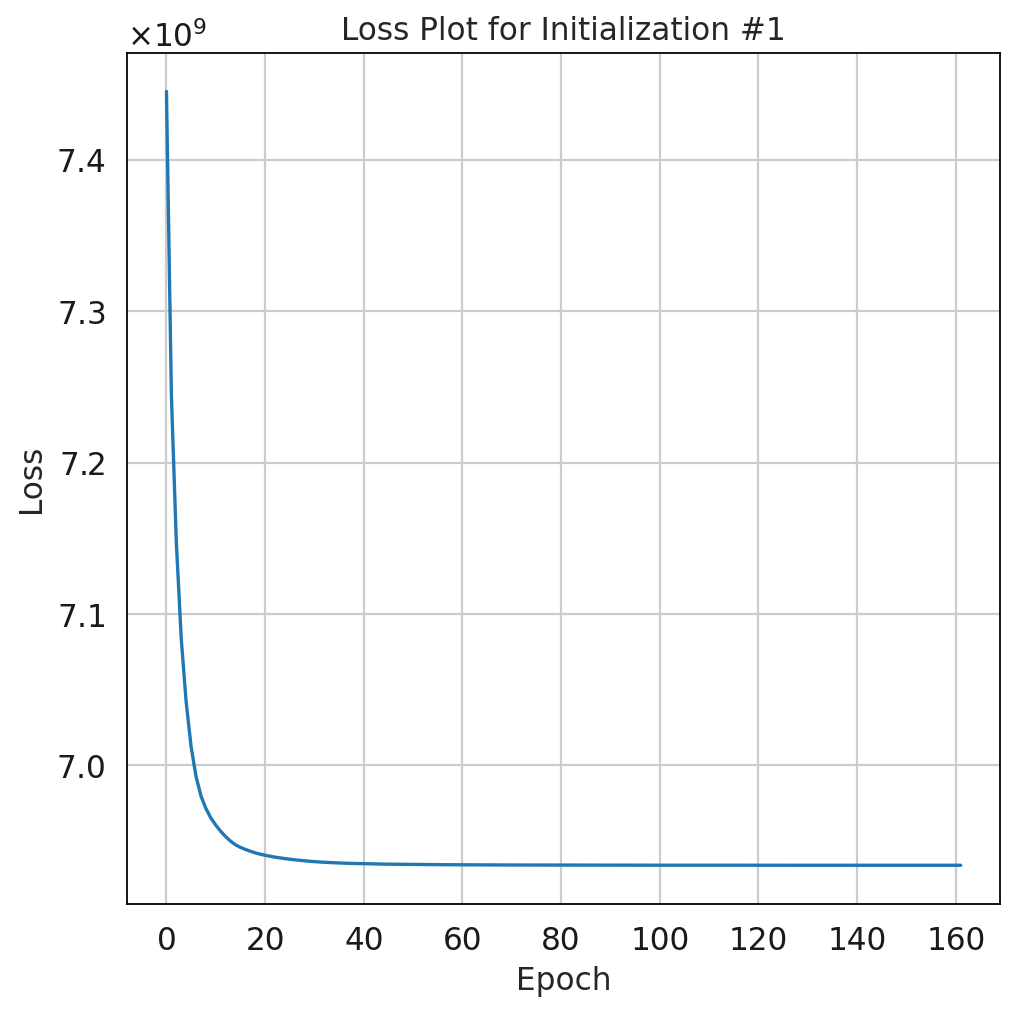

In [29]:
print("Training LeafletFA model...")
easysci_leaflet_model.train(num_initializations=1)

In [30]:
print("Training complete, extracting results...")
easysci_leaflet_model.get_all_variables()

# Save latent variables
gtex_anndata.obsm[f"X_leafletFA_K{K}"] = easysci_leaflet_model.assign_post

# Make a quick barplot of PI and add to wandb log 
alpha_pi=easysci_leaflet_model.alpha_pi
PI = easysci_leaflet_model.pi
PI_df = pd.DataFrame(PI, columns=["PI"])


Training complete, extracting results...
The best initialization was 0 with an ELBO of 6934015404.667333
Extracting all variables from initialization #0
Extracting PSI variational parameters...
PSI was fixed during inference. Using the provided fixed PSI instead of learned variational parameters.
PSI parameters extraction completed.
Extracting the learned beta-binomial concentration (if applicable)...
Extracting the latent representation, C x K matrix of factor activities...
Extracting the learned Pi vector...


In [ ]:
import scanpy as sc
import umap

# Extract the learned embedding from obsm
embedding = gtex_anndata.obsm['X_leafletFA_K20']

# Create UMAP from the LeafletFA embedding
umap_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

# Fit UMAP on the LeafletFA embedding
umap_embedding = umap_reducer.fit_transform(embedding)

# Store UMAP coordinates in standard scanpy location
gtex_anndata.obsm['X_umap'] = umap_embedding

Number of tissues: 30


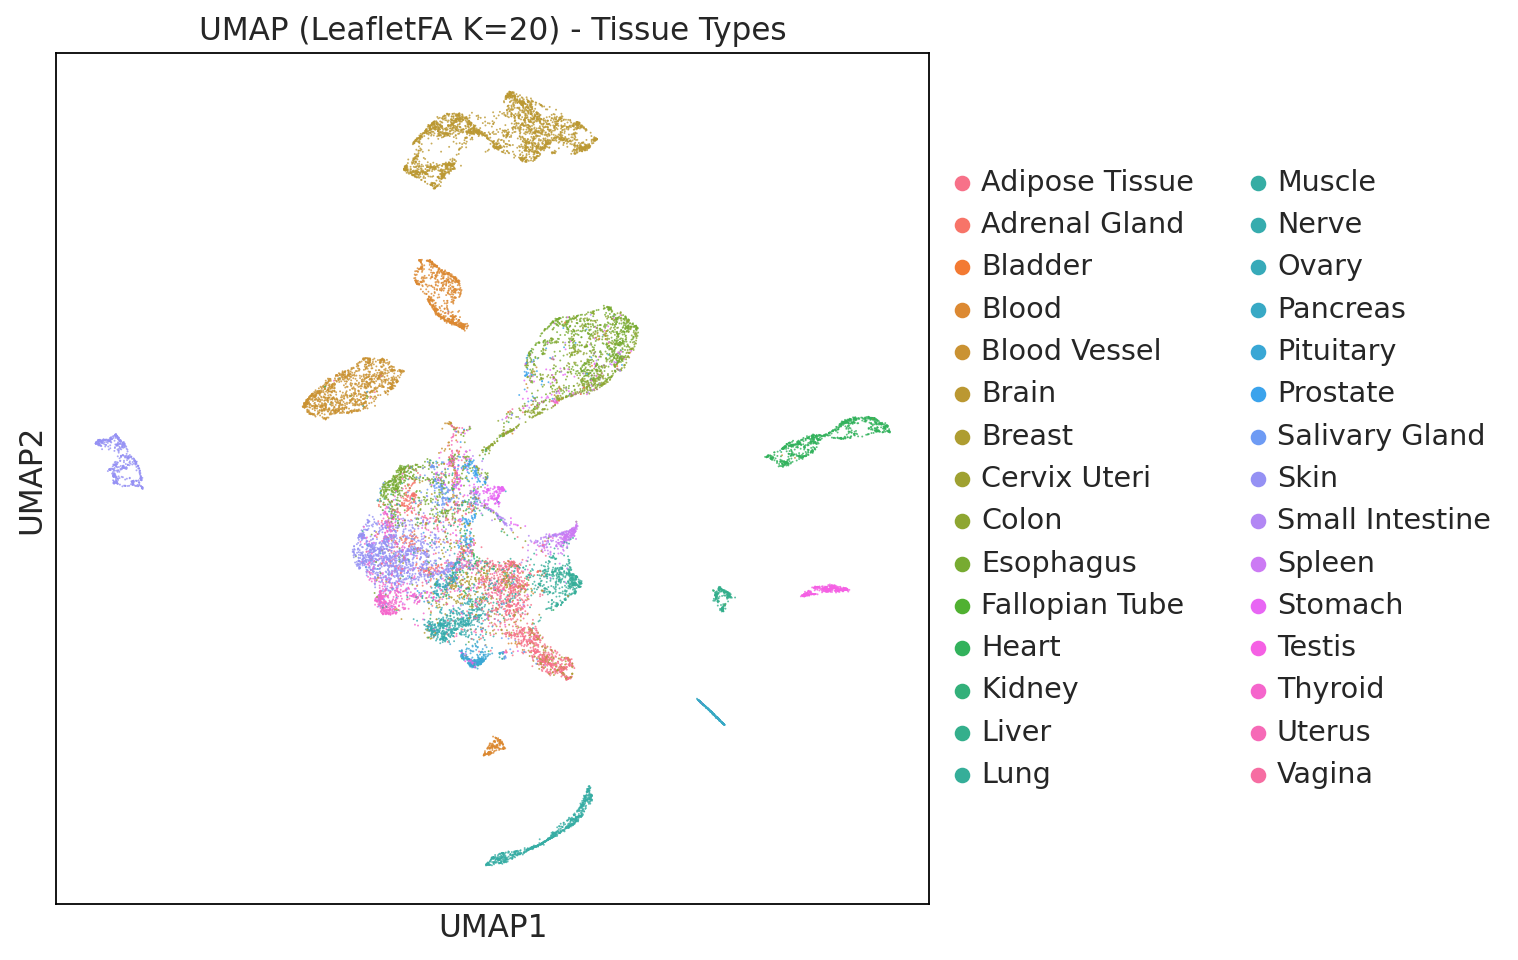

In [50]:
# Get number of unique tissues
n_tissues = gtex_anndata.obs['SMTS'].nunique()
print(f"Number of tissues: {n_tissues}")

# Automatically generate enough distinct colors using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Use seaborn's husl palette for maximally distinct colors
colors_hex = sns.color_palette("husl", n_tissues).as_hex()

# Plot using the auto-generated colors
sc.pl.umap(gtex_anndata, color='SMTS', 
          palette=colors_hex,
          size=3, 
          alpha=0.8,
          legend_loc='right margin',
          title='UMAP (LeafletFA K=20) - Tissue Types')

In [59]:
# Method 3: View first few rows with all columns (no truncation)
print("\n" + "="*50)
print("First 3 rows with all columns:")
print("="*50)
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Don't wrap
pd.set_option('display.max_colwidth', 50)   # Limit column width
print(gtex_anndata.obs.head(3))


First 3 rows with all columns:
                         SMATSSCR SMCENTER  \
SAMPID                                       
GTEX-1117F-0226-SM-5GZZ7        0       B1   
GTEX-1117F-0426-SM-5EGHI        0       B1   
GTEX-1117F-0526-SM-5EGHJ        0       B1   

                                                                   SMPTHNTS  \
SAMPID                                                                        
GTEX-1117F-0226-SM-5GZZ7       2 pieces, ~15% vessel stroma, rep delineated   
GTEX-1117F-0426-SM-5EGHI  2 pieces, !5% fibrous connective tissue, delin...   
GTEX-1117F-0526-SM-5EGHJ  2 pieces, clean, Monckebeg medial sclerosis, r...   

                         SMRIN            SMTS                   SMTSD  \
SAMPID                                                                   
GTEX-1117F-0226-SM-5GZZ7   6.8  Adipose Tissue  Adipose - Subcutaneous   
GTEX-1117F-0426-SM-5EGHI   7.1          Muscle       Muscle - Skeletal   
GTEX-1117F-0526-SM-5EGHJ     8    Blood Vesse

In [60]:
# Load the age data 
age_data_file = "/gpfs/commons/groups/knowles_lab/Karin/data/GTEx/v10/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
age_data = pd.read_csv(age_data_file, sep="\t")
age_data.head()

,SUBJID,SEX,AGE,DTHHRDY
0,GTEX-1117F,2,60-69,4.0
1,GTEX-111CU,1,50-59,0.0
2,GTEX-111FC,1,60-69,1.0
3,GTEX-111VG,1,60-69,3.0
4,GTEX-111YS,1,60-69,0.0


In [67]:
# get SUBJID from SAMPID split by "-" and keep first and second part
gtex_anndata.obs["SUBJID"] = gtex_anndata.obs.index.str.split("-").str[0] + "-" + gtex_anndata.obs.index.str.split("-").str[1]
# now merge with age_data on SUBJID
gtex_anndata.obs = gtex_anndata.obs.merge(age_data, on="SUBJID")
gtex_anndata.obs.head()

,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,SMNABTCH,SMNABTCHT,SMNABTCHD,SMGEBTCH,SMGEBTCHD,SMGEBTCHT,SMAFRZE,SMGTC,SME2MPRT,SMCHMPRS,SMNTRART,SMNUMGPS,SMMAPRT,SMEXNCRT,SM550NRM,SMGNSDTC,SMUNMPRT,SM350NRM,SMRDLGTH,SMMNCPB,SME1MMRT,SMSFLGTH,SMESTLBS,SMMPPD,SMNTERRT,SMRRNANM,SMRDTTL,SMVQCFL,SMMNCV,SMTRSCPT,SMMPPDPR,SMCGLGTH,SMGAPPCT,SMUNPDRD,SMNTRNRT,SMMPUNRT,SMEXPEFF,SMMPPDUN,SME2MMRT,SME2ANTI,SMALTALG,SME2SNSE,SMMFLGTH,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS,n_counts,n_junctions_detected,SUBJID,SEX,AGE,DTHHRDY
0,0,B1,"2 pieces, ~15% vessel stroma, rep delineated",6.8,Adipose Tissue,Adipose - Subcutaneous,0002190,1214,1125,BP-43693,RNA Extraction from Paxgene-derived Lysate Pla...,09/17/2013,LCSET-4804,03/05/2014,TruSeq.v1,RNASEQ,Unknown,0.986026,345562,0.966793,Unknown,0.990383,0.756726,Unknown,23548,1,Unknown,76,Unknown,0.00240323,136,0,6.68332e+07,0.0329192,209558,6.74822e+07,8.79766e+06,Unknown,23575,3.3158e+07,Unknown,Unknown,0,0.210067,0.990383,0.749449,6.68332e+07,0.00391915,1.44627e+07,8.9149e+06,1.45756e+07,144,1.46488e+07,1.19993e+07,0.00315785,1.46695e+07,50.0354,0.00310538,0.99474,Unknown,0,50.1944,3496599.0,77881,GTEX-1117F,2,60-69,4.0
1,0,B1,"2 pieces, !5% fibrous connective tissue, delin...",7.1,Muscle,Muscle - Skeletal,0011907,1220,1119,BP-43495,RNA Extraction from Paxgene-derived Lysate Pla...,09/12/2013,LCSET-4764,02/09/2014,TruSeq.v1,RNASEQ,Unknown,0.985786,145441,0.978816,Unknown,0.990413,0.838961,Unknown,20246,1,Unknown,76,Unknown,0.00241283,137,0,5.99636e+07,0.0209516,423484,6.05441e+07,9.60146e+06,Unknown,20259,2.97858e+07,Unknown,Unknown,0,0.139855,0.990413,0.830918,5.99636e+07,0.00553754,1.31545e+07,8.38344e+06,1.31258e+07,139,1.31915e+07,1.15502e+07,0.00396788,1.33405e+07,50.2809,0.00699464,0.995041,Unknown,0,49.9455,3153536.0,67247,GTEX-1117F,2,60-69,4.0
2,0,B1,"2 pieces, clean, Monckebeg medial sclerosis, r...",8,Blood Vessel,Artery - Tibial,0007610,1221,1120,BP-43495,RNA Extraction from Paxgene-derived Lysate Pla...,09/12/2013,LCSET-4764,02/09/2014,TruSeq.v1,RNASEQ,Unknown,0.983859,223040,0.97136,Unknown,0.98893,0.767837,Unknown,22193,1,Unknown,76,Unknown,0.00263069,126,0,5.98394e+07,0.0283102,173556,6.05092e+07,9.40759e+06,Unknown,22218,2.9681e+07,Unknown,Unknown,0,0.203524,0.98893,0.759337,5.98394e+07,0.00592874,1.29512e+07,6.13979e+06,1.30901e+07,125,1.31754e+07,1.10003e+07,0.00427126,1.31509e+07,49.9535,0.00286826,0.994001,Unknown,0,50.2667,3115848.0,74863,GTEX-1117F,2,60-69,4.0
3,1,B1,"2 pieces, up to 4mm aderent fat/nerve/vessel, ...",6.9,Blood Vessel,Artery - Coronary,0001621,1243,1098,BP-43956,RNA Extraction from Paxgene-derived Lysate Pla...,09/25/2013,LCSET-4904,03/22/2014,TruSeq.v1,RNASEQ,Unknown,0.990294,174501,0.970076,Unknown,0.991275,0.76982,Unknown,23331,1,Unknown,76,Unknown,0.0030529,136,0,6.98592e+07,0.0296435,376087,7.0474e+07,3.63312e+06,Unknown,23354,3.47665e+07,Unknown,Unknown,0,0.200257,0.991275,0.763103,6.98592e+07,0.00367148,1.51676e+07,6.12486e+06,1.52201e+07,151,1.51642e+07,1.16179e+07,0.00336188,1.52919e+07,50.2096,0.00533653,0.992257,Unknown,0,50.0865,3287964.0,77278,GTEX-1117F,2,60-69,4.0
4,1,B1,"2 pieces, no abnormalities",6.3,Heart,Heart - Atrial Appendage,0006631,1244,1097,BP-44261,RNA Extraction from Paxgene-derived Lysate Pla...,10/03/2013,LCSET-4796,02/27/2014,TruSeq.v1,RNASEQ,Unknown,0.990734,184394,0.97883,Unknown,0.993223,0.803478,Unknown,22000,1,Unknown,76,Unknown,0.00311411,131,0,6.28857e+07,0.0208913,1.93643e+06,6.33148e+07,8.25297e+06,Unknown,22015,3.12915e+07,Unknown,Unknown,0,0.175352,0.993223,0.798033,6.28857e+07,0.00377222,1.36366e+07,9.07565e+06,1.36128e+07,146,1.36271e+07,9.26607e+06,0.00344234,1.37567e+07,50.2367,0.0305841,0.995711,Unknown,0,49.9563,2652854.0,74103,GTEX-1117F,2,60-69,4.0


Number of tissues: 54


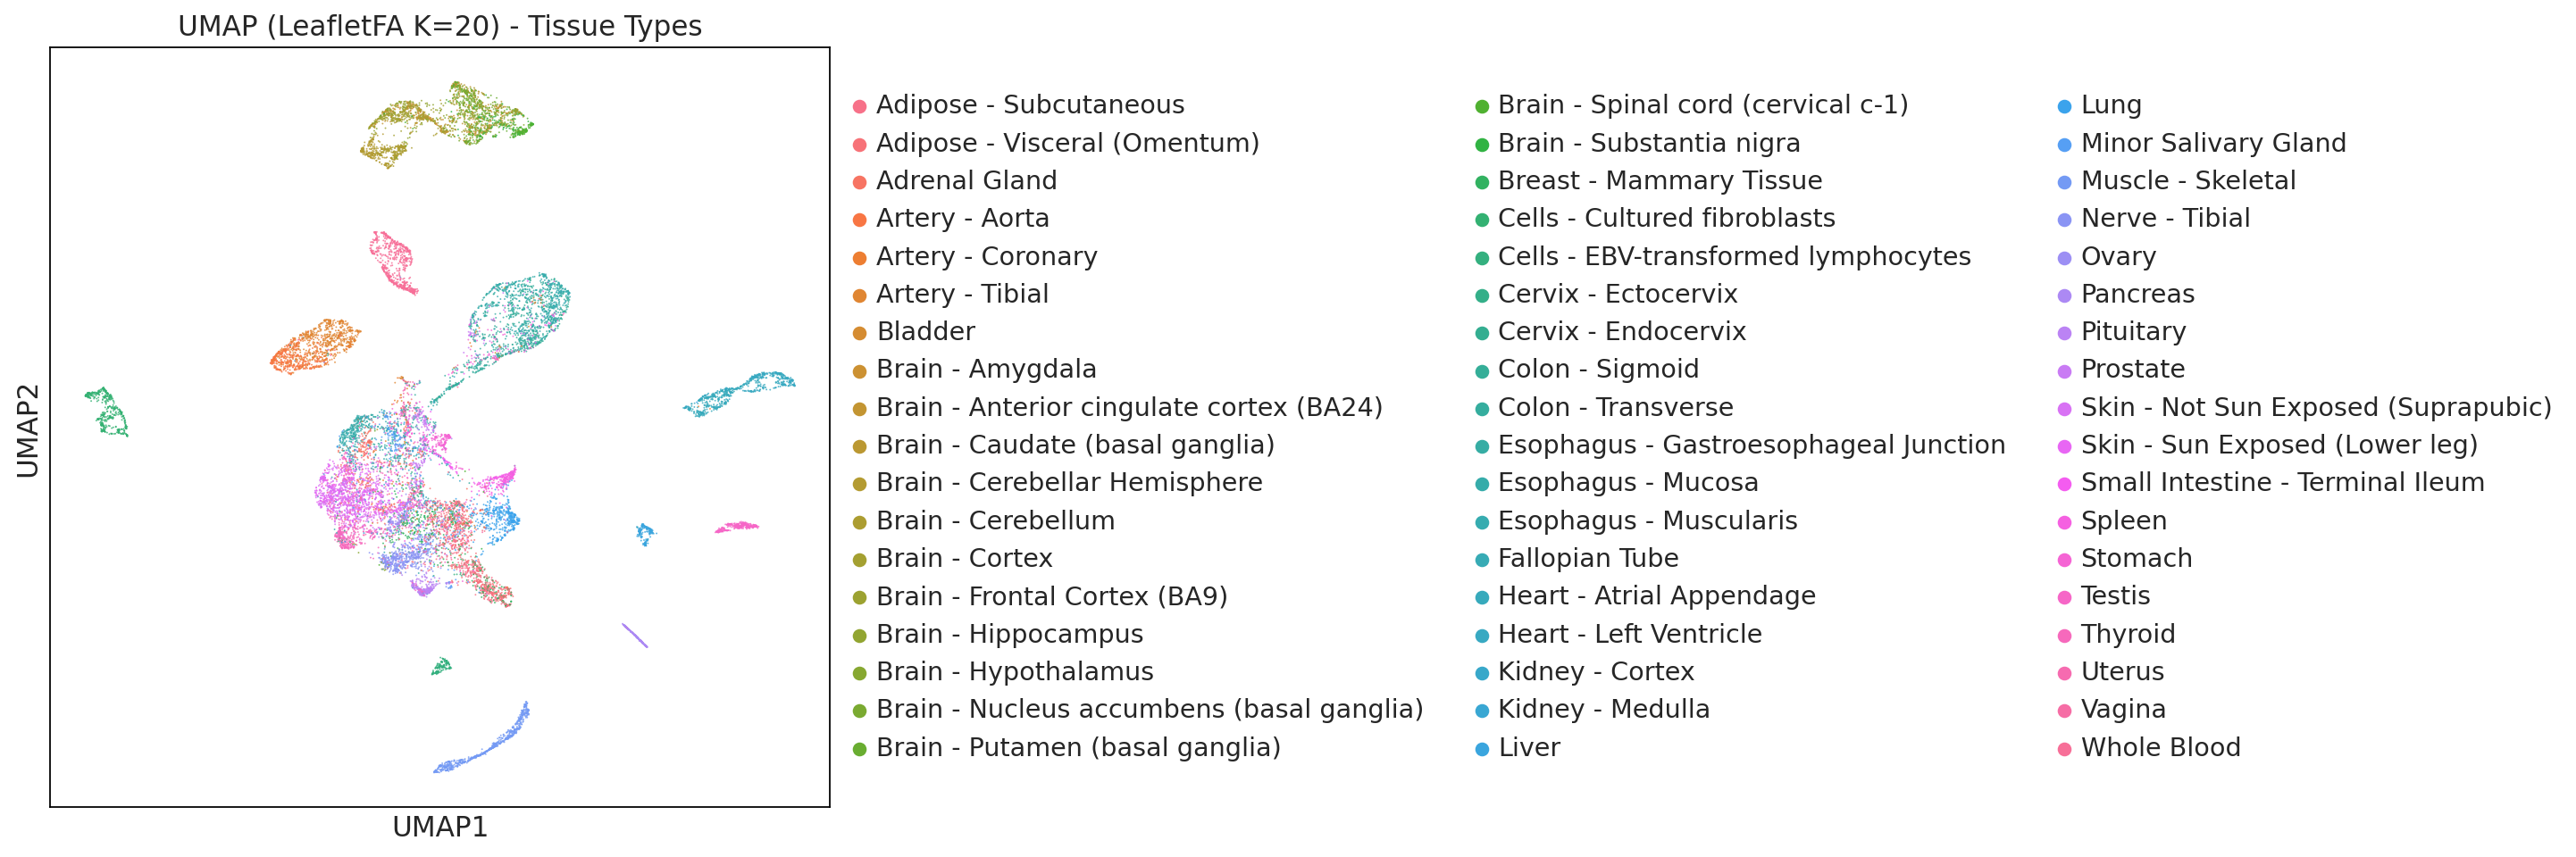

In [57]:
# Get number of unique tissues
n_tissues = gtex_anndata.obs['SMTSD'].nunique()
print(f"Number of tissues: {n_tissues}")

# Automatically generate enough distinct colors using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Use seaborn's husl palette for maximally distinct colors
colors_hex = sns.color_palette("husl", n_tissues).as_hex()

# Plot using the auto-generated colors
sc.pl.umap(gtex_anndata, color='SMTSD', 
          palette=colors_hex,
          size=3, 
          alpha=0.8,
          legend_loc='right margin',
          title='UMAP (LeafletFA K=20) - Tissue Types')

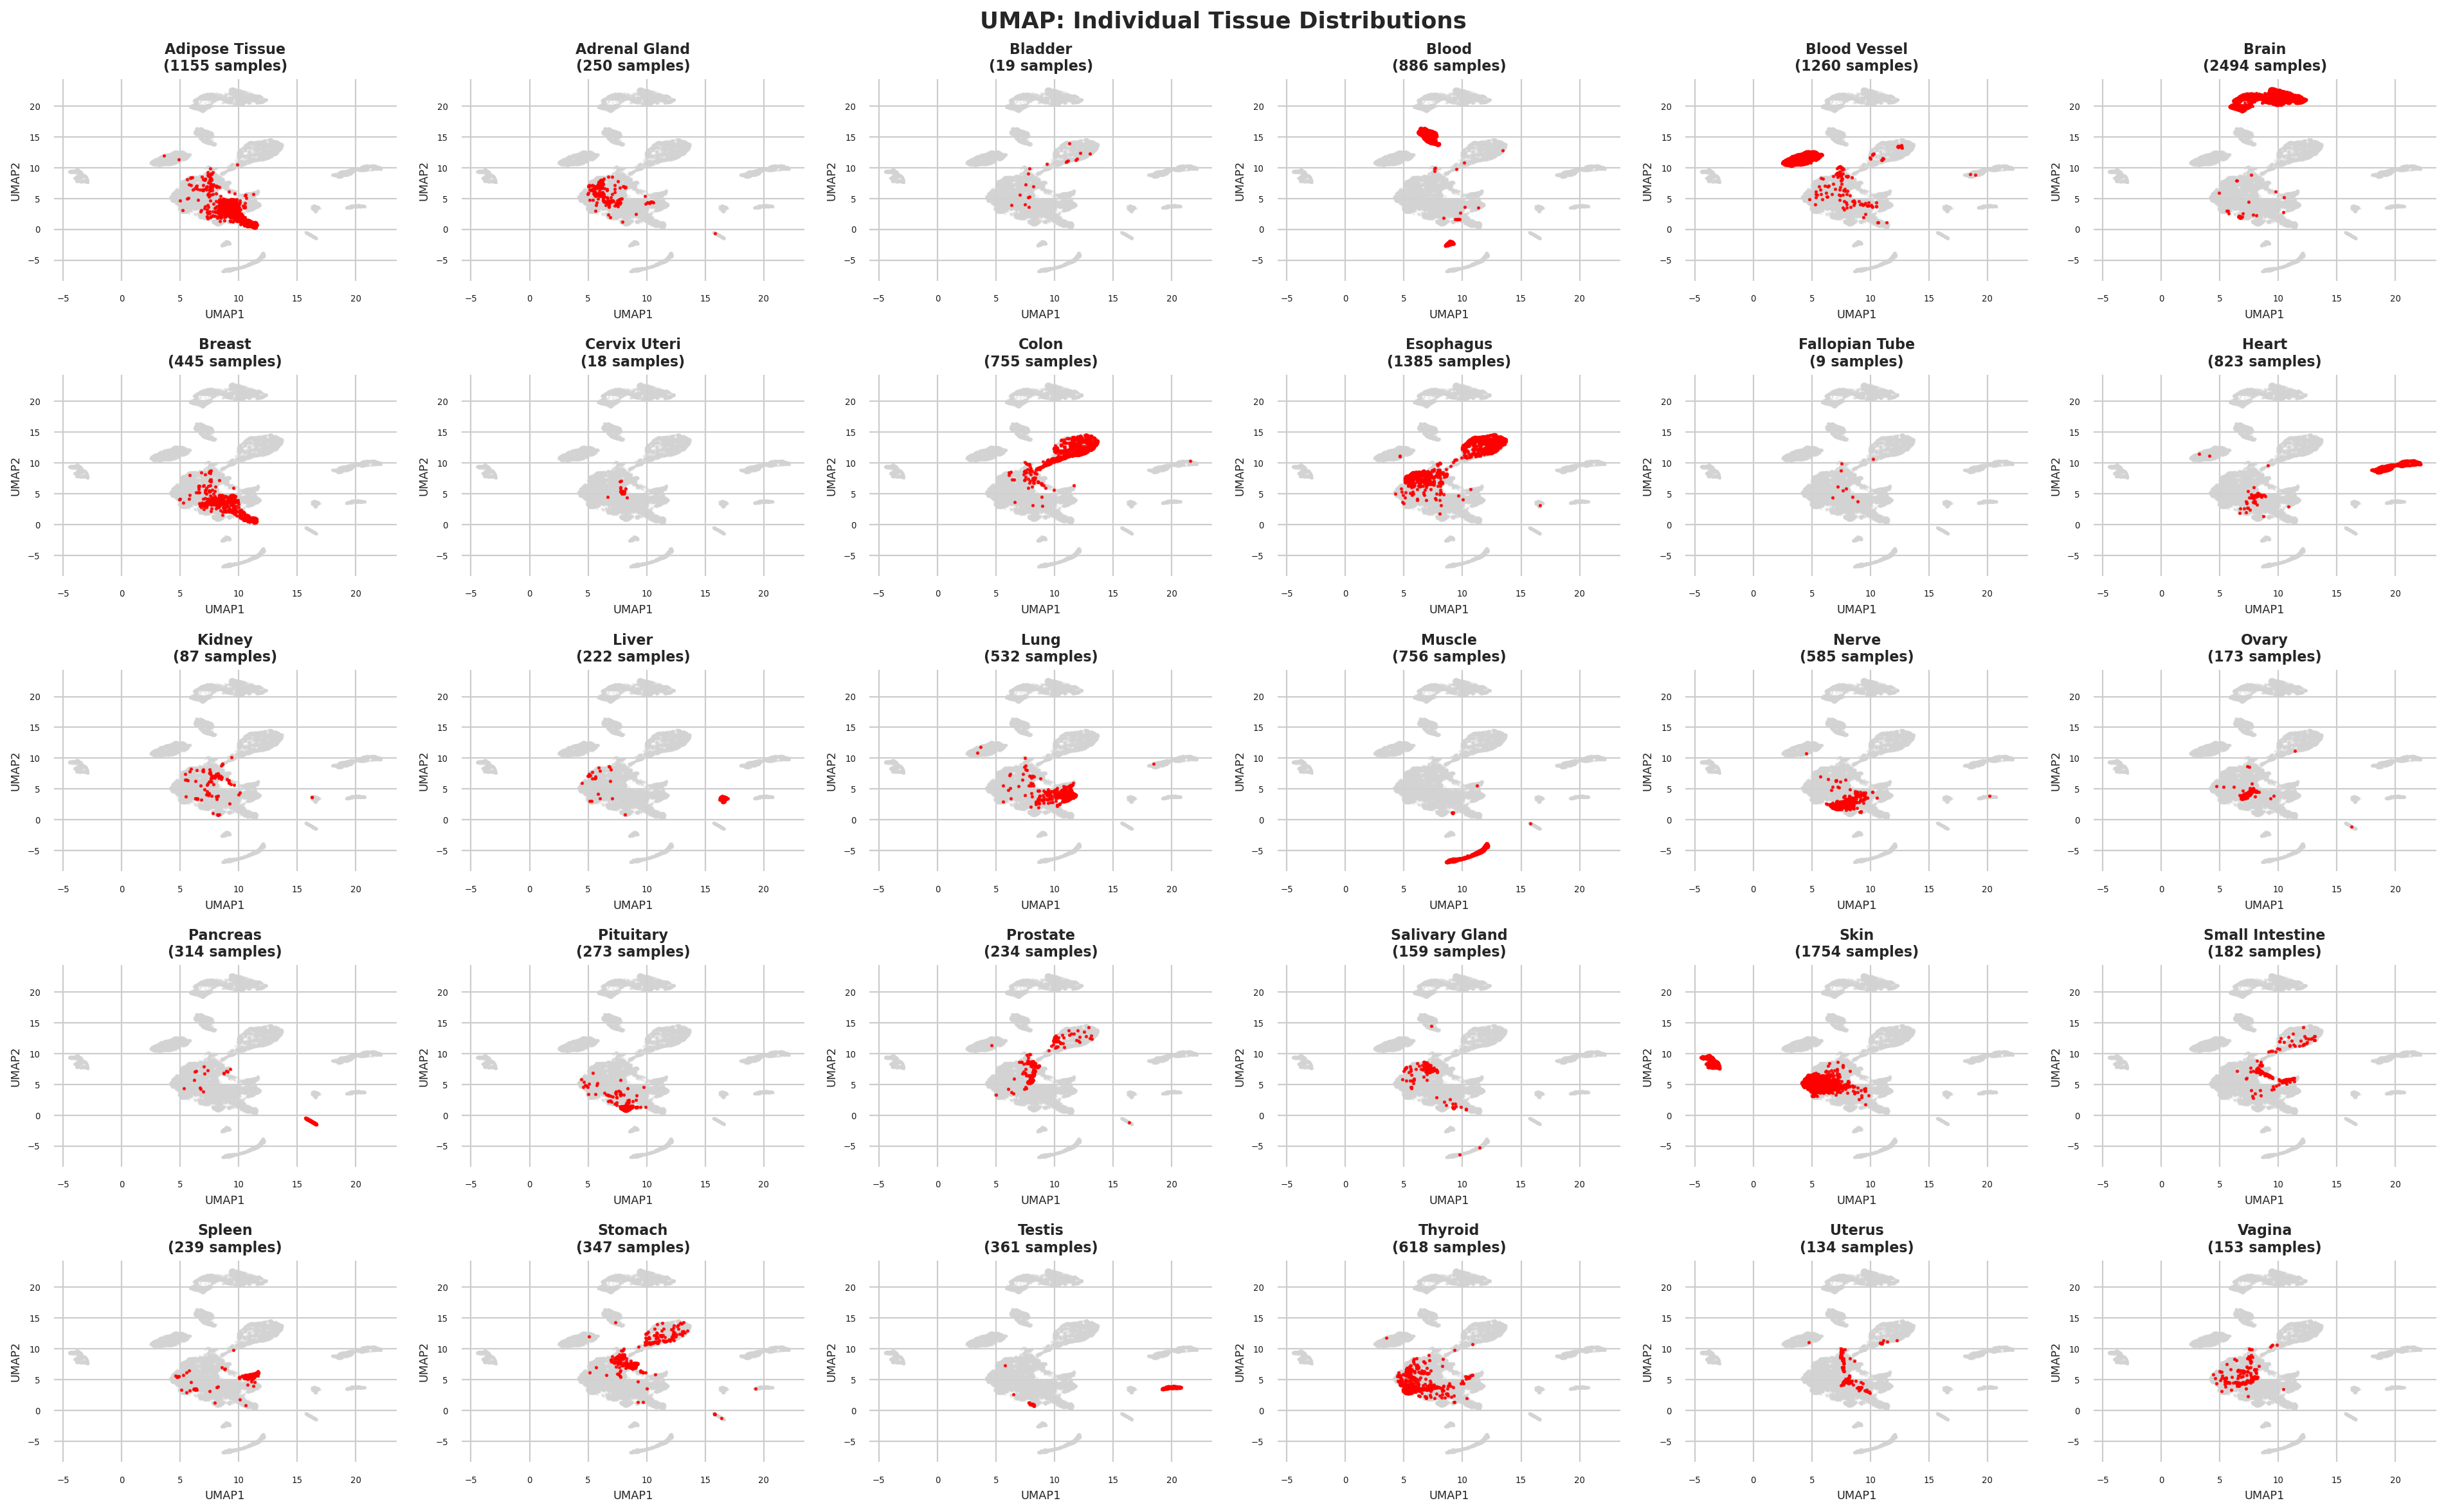

In [55]:
# Get unique tissues
unique_tissues = gtex_anndata.obs['SMTS'].cat.categories
n_tissues = len(unique_tissues)

# Calculate grid dimensions (roughly square)
n_cols = int(np.ceil(np.sqrt(n_tissues)))
n_rows = int(np.ceil(n_tissues / n_cols))

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten() if n_tissues > 1 else [axes]

# Get UMAP coordinates
umap_coords = gtex_anndata.obsm['X_umap']

# Plot each tissue
for i, tissue in enumerate(unique_tissues):
    ax = axes[i]
    
    # Plot all points in light grey
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], 
              c='lightgrey', s=1, alpha=0.3)
    
    # Highlight current tissue
    tissue_mask = gtex_anndata.obs['SMTS'] == tissue
    tissue_coords = umap_coords[tissue_mask]
    
    ax.scatter(tissue_coords[:, 0], tissue_coords[:, 1], 
              c='red', s=2, alpha=0.8)
    
    # Set title and clean up
    ax.set_title(f'{tissue}\n({tissue_mask.sum()} samples)', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('UMAP1', fontsize=8)
    ax.set_ylabel('UMAP2', fontsize=8)
    ax.tick_params(labelsize=6)
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

# Hide extra subplots
for i in range(n_tissues, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('UMAP: Individual Tissue Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Analyzing 20 Splicing Programs (SPs)

Analyzing 27 tissues with ≥50 samples

Analyzing Brain (n=2494)
  SP1: r= 0.047, p=0.0187 ↑
  SP2: r= 0.109, p=0.0000 ↑
  SP3: r= 0.043, p=0.0311 ↑
  SP4: r= 0.111, p=0.0000 ↑
  SP6: r=-0.055, p=0.0056 ↓
  SP8: r= 0.129, p=0.0000 ↑
  SP9: r= 0.083, p=0.0000 ↑
  SP10: r= 0.101, p=0.0000 ↑

Analyzing Skin (n=1754)
  SP1: r= 0.098, p=0.0000 ↑
  SP2: r= 0.057, p=0.0172 ↑
  SP3: r=-0.061, p=0.0103 ↓
  SP5: r=-0.063, p=0.0087 ↓

Analyzing Esophagus (n=1385)
  SP1: r= 0.080, p=0.0027 ↑
  SP2: r= 0.066, p=0.0134 ↑
  SP3: r= 0.067, p=0.0129 ↑
  SP4: r= 0.091, p=0.0007 ↑
  SP6: r=-0.092, p=0.0006 ↓
  SP7: r= 0.134, p=0.0000 ↑
  SP10: r= 0.058, p=0.0310 ↑

Analyzing Blood Vessel (n=1260)
  SP2: r= 0.101, p=0.0003 ↑
  SP3: r=-0.084, p=0.0028 ↓
  SP4: r= 0.113, p=0.0001 ↑
  SP5: r= 0.080, p=0.0043 ↑
  SP6: r=-0.057, p=0.0428 ↓
  SP7: r= 0.065, p=0.0217 ↑
  SP8: r= 0.119, p=0.0000 ↑
  SP9: r= 0.056, p=0.0468 ↑

Analyzing Adipose Tissue (n=1155)
  SP1: r= 0.129, 

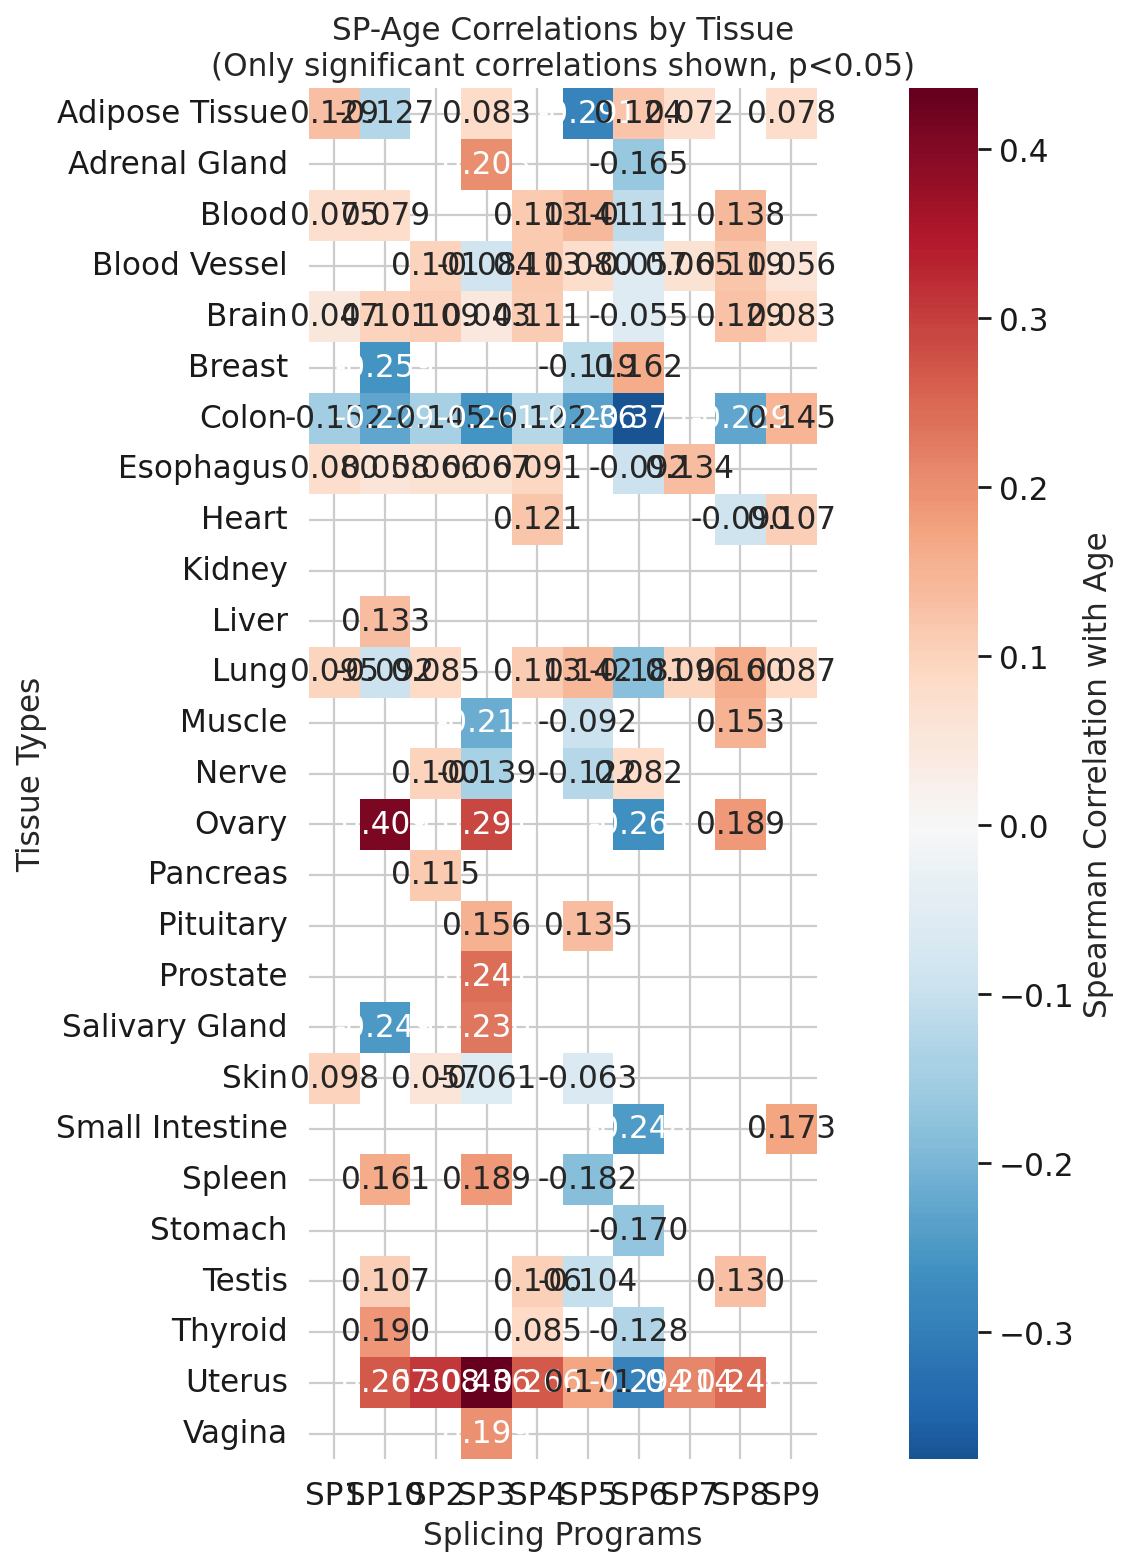


Summary of Significant Correlations:
Total tests performed: 270
Significant correlations: 106 (39.3%)
Strongest positive correlation: 0.436
Strongest negative correlation: -0.375

Top 10 Tissue-SP pairs with strongest age correlations:
  Uterus - SP3: r= 0.436 (p=0.0000) - increases with age
  Ovary - SP10: r= 0.409 (p=0.0000) - increases with age
  Colon - SP6: r=-0.375 (p=0.0000) - decreases with age
  Uterus - SP2: r= 0.308 (p=0.0003) - increases with age
  Uterus - SP6: r=-0.294 (p=0.0006) - decreases with age
  Ovary - SP3: r= 0.291 (p=0.0001) - increases with age
  Adipose Tissue - SP5: r=-0.291 (p=0.0000) - decreases with age
  Uterus - SP10: r= 0.267 (p=0.0018) - increases with age
  Uterus - SP4: r= 0.266 (p=0.0019) - increases with age
  Ovary - SP6: r=-0.265 (p=0.0004) - decreases with age

SP-specific analysis across tissues:

SP1:
  Significant in 7/27 tissues (25.9%)
  Positive correlations: 6, Negative correlations: 1
  Strongest positive: Adipose Tissue (r=0.129)
  Str

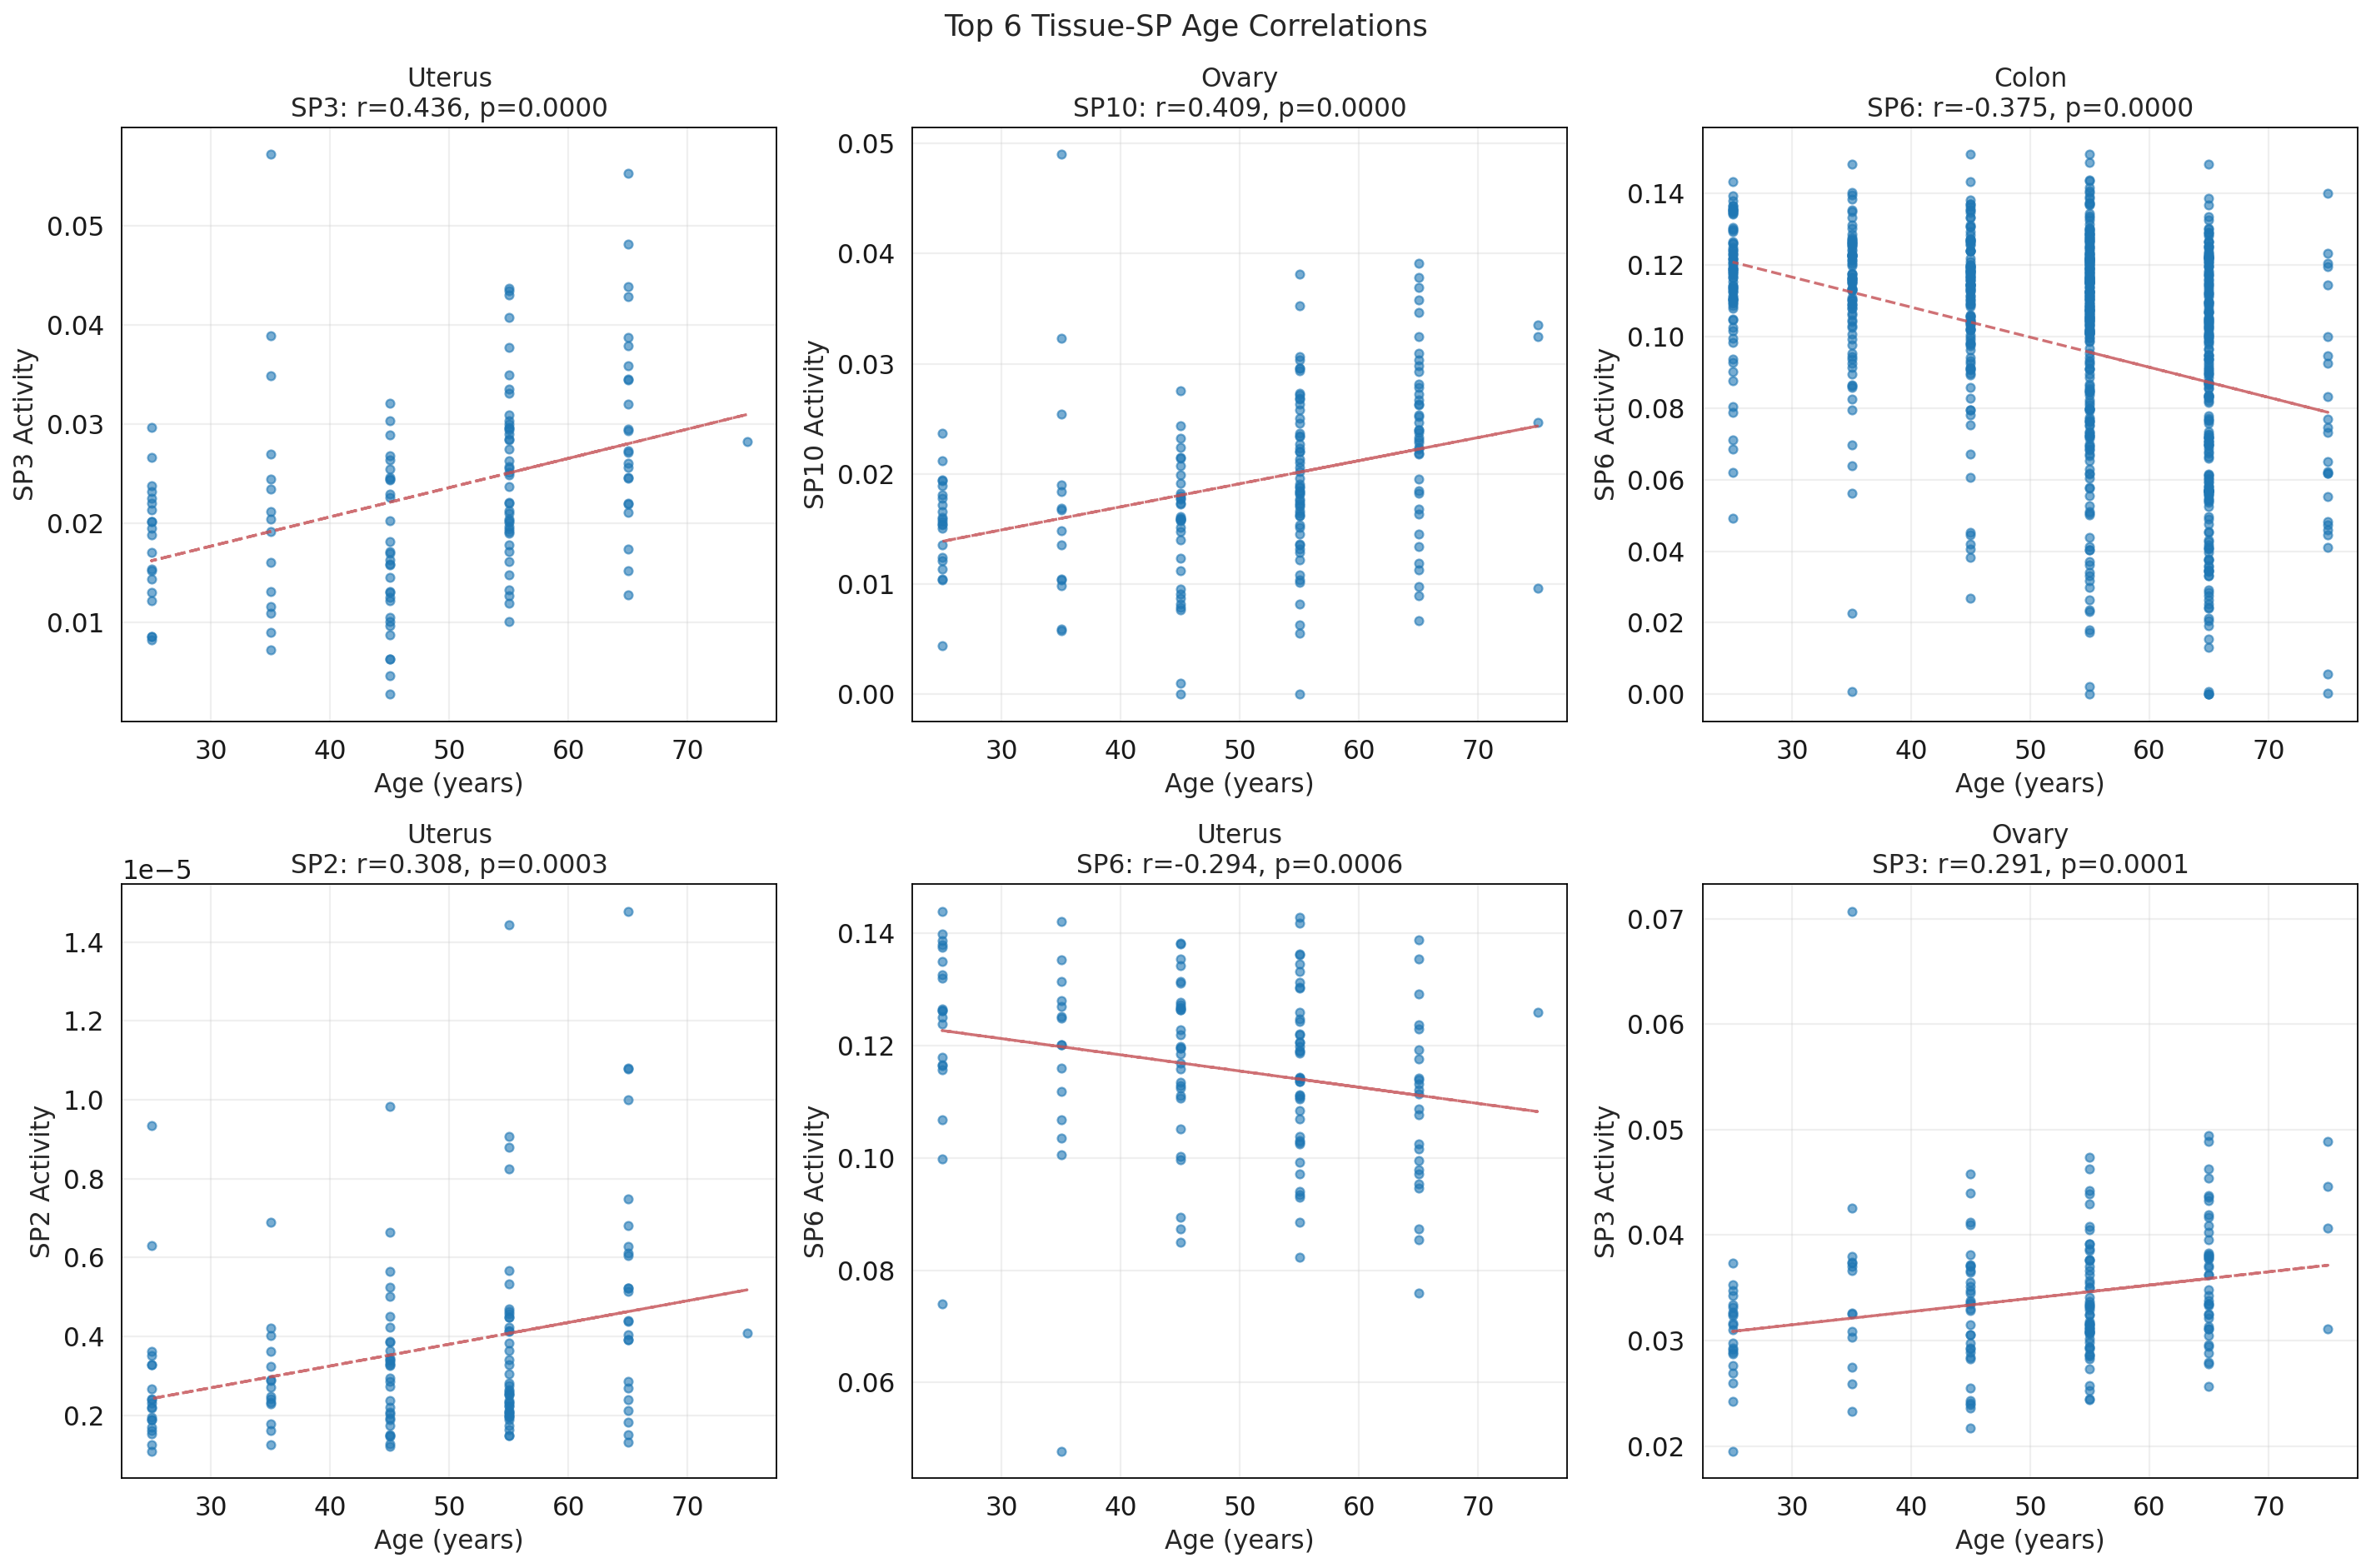


Analysis complete!


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# Extract all SPs from LeafletFA embedding (K=20)
n_sps = gtex_anndata.obsm['X_leafletFA_K20'].shape[1]
print(f"Analyzing {n_sps} Splicing Programs (SPs)")

# Add all SPs to obs
for i in range(n_sps):
    gtex_anndata.obs[f'SP{i+1}'] = gtex_anndata.obsm['X_leafletFA_K20'][:, i]

# Convert age to numeric for correlation
age_numeric = {'20-29': 25, '30-39': 35, '40-49': 45, '50-59': 55, '60-69': 65, '70-79': 75}
gtex_anndata.obs['age_numeric'] = gtex_anndata.obs['AGE'].map(age_numeric)

# Get tissues with sufficient samples for analysis (min 50 samples)
tissue_counts = gtex_anndata.obs['SMTS'].value_counts()
tissues_to_analyze = tissue_counts[tissue_counts >= 50].index.tolist()
print(f"\nAnalyzing {len(tissues_to_analyze)} tissues with ≥50 samples")

# 1. Calculate correlations for each tissue and SP
correlation_results = []

for tissue in tissues_to_analyze:
    tissue_mask = gtex_anndata.obs['SMTS'] == tissue
    tissue_data = gtex_anndata.obs[tissue_mask]
    n_samples = len(tissue_data)
    
    print(f"\nAnalyzing {tissue} (n={n_samples})")
    
    for sp_idx in range(min(10, n_sps)):  # Focus on first 10 SPs for clarity
        sp_name = f'SP{sp_idx+1}'
        
        # Calculate Spearman correlation (robust to outliers)
        corr_coef, p_value = stats.spearmanr(tissue_data['age_numeric'], tissue_data[sp_name])
        
        correlation_results.append({
            'Tissue': tissue,
            'SP': sp_name,
            'SP_idx': sp_idx + 1,
            'Correlation': corr_coef,
            'P_value': p_value,
            'N_samples': n_samples,
            'Significant': p_value < 0.05
        })
        
        # Print significant correlations
        if p_value < 0.05:
            direction = "↑" if corr_coef > 0 else "↓"
            print(f"  {sp_name}: r={corr_coef:6.3f}, p={p_value:.4f} {direction}")

# Convert to DataFrame
corr_df = pd.DataFrame(correlation_results)

# 2. Create heatmap of correlations
print(f"\nCreating correlation heatmap...")

# Pivot for heatmap
heatmap_data = corr_df.pivot(index='Tissue', columns='SP', values='Correlation')

plt.figure(figsize=(12, 10))
mask = corr_df.pivot(index='Tissue', columns='SP', values='P_value') >= 0.05
sns.heatmap(heatmap_data, 
           mask=mask,  # Hide non-significant correlations
           center=0, 
           cmap='RdBu_r', 
           annot=True, 
           fmt='.3f',
           cbar_kws={'label': 'Spearman Correlation with Age'},
           square=True)
plt.title('SP-Age Correlations by Tissue\n(Only significant correlations shown, p<0.05)')
plt.xlabel('Splicing Programs')
plt.ylabel('Tissue Types')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Summary statistics
print("\nSummary of Significant Correlations:")
print("=" * 50)

sig_corr = corr_df[corr_df['Significant']]
total_tests = len(corr_df)
sig_tests = len(sig_corr)

print(f"Total tests performed: {total_tests}")
print(f"Significant correlations: {sig_tests} ({sig_tests/total_tests*100:.1f}%)")

if len(sig_corr) > 0:
    print(f"Strongest positive correlation: {sig_corr.loc[sig_corr['Correlation'].idxmax(), 'Correlation']:.3f}")
    print(f"Strongest negative correlation: {sig_corr.loc[sig_corr['Correlation'].idxmin(), 'Correlation']:.3f}")
    
    # Top tissue-SP pairs
    print(f"\nTop 10 Tissue-SP pairs with strongest age correlations:")
    top_corr = sig_corr.reindex(sig_corr['Correlation'].abs().sort_values(ascending=False).index)
    for idx, row in top_corr.head(10).iterrows():
        direction = "increases" if row['Correlation'] > 0 else "decreases"
        print(f"  {row['Tissue']} - {row['SP']}: r={row['Correlation']:6.3f} (p={row['P_value']:.4f}) - {direction} with age")

# 4. SP-specific analysis across tissues
print(f"\nSP-specific analysis across tissues:")
print("=" * 40)

for sp_idx in range(1, min(11, n_sps+1)):
    sp_name = f'SP{sp_idx}'
    sp_data = corr_df[corr_df['SP'] == sp_name]
    sig_sp = sp_data[sp_data['Significant']]
    
    print(f"\n{sp_name}:")
    print(f"  Significant in {len(sig_sp)}/{len(sp_data)} tissues ({len(sig_sp)/len(sp_data)*100:.1f}%)")
    
    if len(sig_sp) > 0:
        pos_corr = len(sig_sp[sig_sp['Correlation'] > 0])
        neg_corr = len(sig_sp[sig_sp['Correlation'] < 0])
        print(f"  Positive correlations: {pos_corr}, Negative correlations: {neg_corr}")
        
        # Strongest correlations for this SP
        strongest_pos = sig_sp[sig_sp['Correlation'] > 0].nlargest(1, 'Correlation')
        strongest_neg = sig_sp[sig_sp['Correlation'] < 0].nsmallest(1, 'Correlation')
        
        if len(strongest_pos) > 0:
            row = strongest_pos.iloc[0]
            print(f"  Strongest positive: {row['Tissue']} (r={row['Correlation']:.3f})")
        if len(strongest_neg) > 0:
            row = strongest_neg.iloc[0]
            print(f"  Strongest negative: {row['Tissue']} (r={row['Correlation']:.3f})")

# 5. Tissue-specific analysis
print(f"\nTissue-specific analysis:")
print("=" * 30)

for tissue in tissues_to_analyze:
    tissue_data = corr_df[corr_df['Tissue'] == tissue]
    sig_tissue = tissue_data[tissue_data['Significant']]
    
    if len(sig_tissue) > 0:
        print(f"\n{tissue} ({tissue_data.iloc[0]['N_samples']} samples):")
        print(f"  {len(sig_tissue)} significant SP-age correlations")
        
        # Show top correlations for this tissue
        top_tissue_corr = sig_tissue.reindex(sig_tissue['Correlation'].abs().sort_values(ascending=False).index)
        for idx, row in top_tissue_corr.head(3).iterrows():
            direction = "↑" if row['Correlation'] > 0 else "↓"
            print(f"    {row['SP']}: r={row['Correlation']:6.3f} {direction}")

# 6. Create focused plots for top tissue-SP pairs
if len(sig_corr) > 0:
    print(f"\nCreating detailed plots for top correlations...")
    
    # Get top 6 correlations for detailed plotting
    top_6_corr = sig_corr.reindex(sig_corr['Correlation'].abs().sort_values(ascending=False).index).head(6)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, (idx, row) in enumerate(top_6_corr.iterrows()):
        tissue = row['Tissue']
        sp_name = row['SP']
        
        # Get data for this tissue
        tissue_mask = gtex_anndata.obs['SMTS'] == tissue
        tissue_subset = gtex_anndata.obs[tissue_mask]
        
        # Create scatter plot
        axes[i].scatter(tissue_subset['age_numeric'], tissue_subset[sp_name], 
                       alpha=0.6, s=20)
        
        # Add trend line
        z = np.polyfit(tissue_subset['age_numeric'], tissue_subset[sp_name], 1)
        p = np.poly1d(z)
        axes[i].plot(tissue_subset['age_numeric'], p(tissue_subset['age_numeric']), 
                    "r--", alpha=0.8)
        
        axes[i].set_xlabel('Age (years)')
        axes[i].set_ylabel(f'{sp_name} Activity')
        axes[i].set_title(f'{tissue}\n{sp_name}: r={row["Correlation"]:.3f}, p={row["P_value"]:.4f}')
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Top 6 Tissue-SP Age Correlations', fontsize=16)
    plt.tight_layout()
    plt.show()

print(f"\nAnalysis complete!")